In [ ]:
%pip install langchain langchain_community langgraph
%pip install pypdf
%pip install langchain-google-genai
%pip install langchain-nvidia-ai-endpoints 
%pip install faiss-cpu

In [22]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langgraph.graph import START, StateGraph, END
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from dotenv import load_dotenv
load_dotenv()
import os
from typing import TypedDict, List
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
docs = (PyPDFLoader('./docs/Transformers_and_llm.pdf').load()  + PyPDFLoader('./docs/Hands_On_llm.pdf').load() + PyPDFLoader('./docs/Introduction_to_Machine_Learning_with_Python.pdf').load())
docs

In [ ]:
len(docs)

In [ ]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 800, chunk_overlap=100).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode('utf-8', 'ignore').decode('utf-8', 'ignore')

In [10]:
embeddings = NVIDIAEmbeddings(
  model="nvidia/nv-embed-v1", 
  api_key=os.getenv('NVIDIA_EMBEDDINGS_API_KEY'), 
  truncate="NONE", 
  )
vector_store = FAISS.from_documents(chunks, embeddings)

In [42]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [14]:
llm = ChatNVIDIA(
  model="moonshotai/kimi-k2-thinking",
  api_key=os.getenv('NVIDIA_CHAT_API_KEY'), 
  temperature=1,
  top_p=0.9,
  max_tokens=16384,
)

C:\Users\OMM\AppData\Local\Temp\ipykernel_8440\1118434693.py:1: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  llm = ChatNVIDIA(


In [46]:
q='WHat is neural netwrok'
retriever.invoke(q)

[Document(id='423548fd-b6b6-4db5-9cdd-ef272ac1ef81', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': './docs/Introduction_to_Machine_Learning_with_Python.pdf', 'total_pages': 392, 'page': 131, 'page_label': '118'}, page_content='This brings us to the downsides. Neural networks—particularly the large and power‐\nful ones—often take a long time to train. They also require careful preprocessing of\nthe data, as we saw here. Similarly to SVMs, they work best with “homogeneous”\ndata, where all the features have similar meanings. For data that has very different\nkinds of features, tree-based models might work better. Tuning neural network

In [19]:
class State(TypedDict):
    question: str
    context: List[Document]
    result: str

In [47]:
def retrieve(state: State):
    q=state['question']
    return {'context': retriever.invoke(q)}

In [55]:
prompt = ChatPromptTemplate(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

def generator(state: State):
    context = '\n\n'.join(d.page_content for d in state['context'])
    out = (prompt | llm).invoke({'question': state['question'], 'context': context})
    return {'result': out.content}

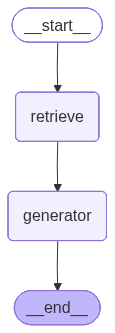

In [56]:
g = StateGraph(State)
g.add_node('retrieve', retrieve)
g.add_node('generator', generator)

g.add_edge(START, 'retrieve')
g.add_edge('retrieve', 'generator')
g.add_edge('generator', END)

workflow= g.compile()
workflow

In [57]:
resp = workflow.invoke({'question': 'What is transformer?', 'context': [], 'answer': ''})
print(resp)

{'question': 'What is transformer?', 'context': [Document(id='17f2f5ff-93ff-40e7-8be4-d4ca01f3acfa', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-02-03T15:00:33-08:00', 'author': '', 'title': '', 'subject': '', 'keywords': '', 'moddate': '2024-02-03T15:00:33-08:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'source': './docs/Transformers_and_llm.pdf', 'total_pages': 30, 'page': 2, 'page_label': '3'}, page_content='10.1 • T HE TRANSFORMER : A S ELF -ATTENTION NETWORK 3\ntransformers are a neural architecture that can handle distant information. But unlike\nLSTMs, transformers are not based on recurrent connections (which can be hard to\nparallelize), which means that transformers can be more efﬁcient to implement at\nscale.\nTransformers are made up of stacks of transformer blocks, each of which is a\nmultilayer network that maps sequences of input ve

In [58]:
print(resp['result'])

 A transformer is a neural architecture introduced in 2017 that can handle distant information without using recurrent connections, making it more efficient to implement at scale compared to models like LSTMs. 

It is built from stacks of transformer blocks, where each block is a multilayer network that maps sequences of input vectors to sequences of output vectors of the same length. These blocks combine simple linear layers, feedforward networks, and self-attention layers—the key innovation of transformers. Self-attention layers map input sequences to output sequences of the same length using attention heads that model how surrounding words are relevant for processing the current word.

A transformer block consists of a single attention layer followed by a feed-forward layer, with residual connections and layer normalizations after each component. These blocks can be stacked to create deeper and more powerful networks. For language modeling, stacks of transformer blocks are topped wi